In [2]:
%pip install numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 3.0 MB/s  0:00:05m0:00:0100:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 2.7 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 2.9 MB/s  0:00:12m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]
Note: you may need to restart the kernel to use updated packages.


In [14]:
%pip install seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 6.6 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [seaborn]m3/4 [seaborn]
Note: you may need to restart the kernel to use updated packages.


In [1]:
import os
import numpy as np
from PIL import Image

import torch
from torch.utils.data import Dataset

In [2]:
class SegmentationDataset(Dataset):
    def __init__(self, auth_img_dir, forged_img_dir, forged_mask_dir, target_size = (256, 320)):
        self.samples = []
        self.target_size = target_size

        for img in os.listdir(auth_img_dir):
            if img.lower().endswith((".jpg", ".png", ".jpeg")):
                self.samples.append({
                    "image_path": os.path.join(auth_img_dir, img),
                    "mask_path": None,
                    "type": "authentic"
                })

        for img in os.listdir(forged_img_dir):
            if img.lower().endswith((".jpg", ".png", ".jpeg")):
                self.samples.append({
                    "image_path": os.path.join(forged_img_dir, img),
                    "mask_path": os.path.join(
                        forged_mask_dir,
                        os.path.splitext(img)[0] + ".npy"
                    ),
                    "type": "forged"
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image = Image.open(sample["image_path"]).convert("RGB")
        image = image.resize(self.target_size)
        image = np.array(image, dtype=np.float32) / 255.0

        height, width, _ = image.shape

        if sample["type"] == "authentic":
            mask = np.zeros((height, width), dtype=np.float32)

        else:
            mask = np.load(sample["mask_path"]).astype(np.float32)

            if mask.ndim == 3:
                mask = mask[0]

            mask = (mask > 0).astype(np.float32)

            mask = Image.fromarray(mask)
            mask = mask.resize(self.target_size, Image.NEAREST)
            mask = np.array(mask, dtype = np.float32)


        image = np.transpose(image, (2, 0, 1))   # C × H × W
        mask = np.expand_dims(mask, axis=0)      # 1 × H × W

        image = torch.from_numpy(image)
        mask = torch.from_numpy(mask)

        return image, mask



In [3]:
auth_img_dir = "data/train_images/authentic"
forged_img_dir = "data/train_images/forged"
forged_mask_dir = "data/train_masks"


dataset = SegmentationDataset(auth_img_dir, forged_img_dir, forged_mask_dir )

In [5]:
image, mask = dataset[0]

print(torch.unique(mask))
print(mask.sum())

tensor([0.])
tensor(0.)


In [6]:
for i in [0, 10, 100]:
    image, mask = dataset[i]
    print(f"Sample {i}: unique={torch.unique(mask)}, sum={mask.sum()}")


Sample 0: unique=tensor([0.]), sum=0.0
Sample 10: unique=tensor([0.]), sum=0.0
Sample 100: unique=tensor([0.]), sum=0.0


In [7]:
idx = len(dataset) - 1
image, mask = dataset[idx]

print(mask.shape)
print(torch.unique(mask))
print(mask.sum())
print(image.shape)


torch.Size([1, 320, 256])
tensor([0., 1.])
tensor(1665.)
torch.Size([3, 320, 256])


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size = 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size = 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)
    

class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size = 2, stride = 2)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size = 2, stride = 2)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size = 2, stride = 2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size = 1)


    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)





In [62]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet().to(device)
criterion = nn.BCEWithLogitsLoss()

image, mask = dataset[len(dataset) - 1]
image = image.unsqueeze(0).to(device)
mask = mask.unsqueeze(0).to(device)

output = model(image)

print("Output Shape: ", output.shape)
loss = criterion(output, mask)
print("Loss: ", loss.item())

loss.backward()
print("Backward pass successful")

Output Shape:  torch.Size([1, 1, 320, 256])
Loss:  0.7203633189201355
Backward pass successful


In [10]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

In [11]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)
print(torch.unique(masks))

torch.Size([4, 3, 320, 256])
torch.Size([4, 1, 320, 256])
tensor([0., 1.])


In [12]:
images, masks = next(iter(train_loader))

print("images: ", images.shape, images.dtype, images.min().item(), images.max().item())
print("masks: ", masks.shape, masks.dtype, masks.min().item(), masks.max().item())

images:  torch.Size([4, 3, 320, 256]) torch.float32 0.0 1.0
masks:  torch.Size([4, 1, 320, 256]) torch.float32 0.0 1.0


In [ ]:
device = "cuda"
model = UNet().to(device)

images = images.to(device)

masks = masks.to(device)

criterion = torch.nn.BCEWithLogitsLoss()

In [ ]:
model.train()

outputs = model(images)
loss = criterion(outputs, masks)

print("loss: ", loss.item())

loss.backward()
print("backward pass successful")

In [19]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

model.train()

for step in range(200):
    optimizer.zero_grad()

    outputs = model(images)
    loss = criterion(outputs, masks)

    loss.backward()
    optimizer.step()

    if step % 20 == 0:
        print(f"step {step:03d} | Loss: {loss.item():.4f}")

step 000 | Loss: 0.9038
step 020 | Loss: 0.4261
step 040 | Loss: 0.2827
step 060 | Loss: 0.2168
step 080 | Loss: 0.1608
step 100 | Loss: 0.1199
step 120 | Loss: 0.0887
step 140 | Loss: 0.0685
step 160 | Loss: 0.0541
step 180 | Loss: 0.0434


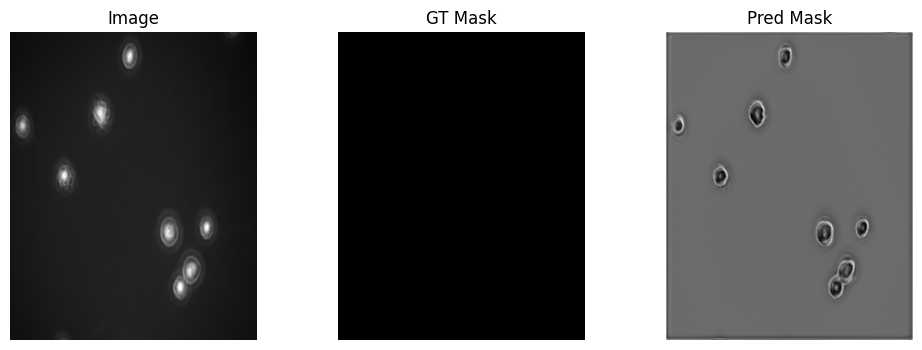

In [21]:
import matplotlib.pyplot as plt
import torch

model.eval()
with torch.no_grad():
    preds = torch.sigmoid(model(images))

i = 0
img = images[i].cpu().permute(1, 2, 0)
gt = masks[i, 0].cpu()
pd = preds[i, 0].cpu()

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.title("Image"); plt.imshow(img); plt.axis("off")
plt.subplot(1, 3, 2); plt.title("GT Mask"); plt.imshow(gt, cmap="grey"); plt.axis("off")
plt.subplot(1, 3, 3); plt.title("Pred Mask"); plt.imshow(pd, cmap="grey"); plt.axis("off")
plt.show()


In [4]:
from torch.utils.data import random_split, DataLoader

dataset_size = len(dataset)
val_size = int(0.2 * dataset_size)
train_size = dataset_size - val_size

train_dataset, val_dataset = random_split(
    dataset, [train_size, val_size]
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=4,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

In [6]:
device = "cuda"

model = UNet().to(device)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

In [9]:
class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps


    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection =  (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
        dice = (2 * intersection + self.eps) / (union + self.eps)
        return 1 - dice.mean()

In [12]:
bce = nn.BCEWithLogitsLoss()
dice = DiceLoss()

def combined_loss(logits, targets):
    bce_loss = bce(logits, targets)
    
    if targets.sum() > 0:
        dice_loss = dice(logits, targets)
        return dice_loss
    
    else:
        return bce_loss

In [5]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0

    for images, masks in loader:
        images = images.to(device, non_blocking = True)
        masks = masks.to(device, non_blocking = True)

        optimizer.zero_grad(set_to_none=True)
        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [6]:
def validate_one_epoch(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device , non_blocking = True)
            masks = masks.to(device , non_blocking = True)

            outputs = model(images)
            loss = criterion(outputs, masks)

            running_loss += loss.item()

    return running_loss / len(loader)

In [24]:
num_epochs = 25

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

torch.save(model.state_dict(), "unet_baseline.pth")

KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
import cv2
def postprocess_mask(mask, prob_map, min_area=100, min_conf=0.6):
    if isinstance(mask, torch.Tensor):
        mask = mask.cpu().numpy()

    if isinstance(prob_map, torch.Tensor):
        prob_map = prob_map.cpu().numpy()

    mask = mask.astype(np.uint8)

    num_labels, labels, stats, _  = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    clean = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        
        if area >= min_area:
            region_probs = prob_map[labels == i]
            mean_conf = region_probs.mean()

            if mean_conf >= min_conf:
                clean[labels == i] = 1

    return clean

In [ ]:
# def adaptive_threshold(prob_map):
#     return prob_map.mean() + 0.5 * prob_map.std()

In [72]:
import matplotlib.pyplot as plt
import torch

def visualize_batch(model, loader, device, max_samples=3, conf_gate=0.15, quantile=0.99):
    model.eval()
    images, masks = next(iter(loader))

    images = images.to(device)
    masks = masks.to(device)

    with torch.no_grad():
        logits = model(images)
        probs = torch.sigmoid(logits)

    for i in range(min(max_samples, images.size(0))):
        img = images[i].cpu().permute(1, 2, 0)
        gt = masks[i, 0].cpu()
        prob_map = probs[i, 0]

        if prob_map.max() < conf_gate:
            pr_bin = torch.zeros_like(prob_map)
        else:
            thr = torch.quantile(prob_map, quantile)
            pr_bin = (prob_map >= thr).float()
            
        pr = postprocess_mask(pr_bin, probs[i, 0], min_area=100, min_conf=0.6)

        plt.figure(figsize=(12, 4))
        plt.subplot(1,3,1); plt.title("image"); plt.imshow(img); plt.axis("off")
        plt.subplot(1,3,2); plt.title("GT Mask"); plt.imshow(gt, cmap="grey"); plt.axis("off")
        plt.subplot(1,3,3); plt.title("Pred Mask"); plt.imshow(pr, cmap="grey"); plt.axis("off")
        plt.show()

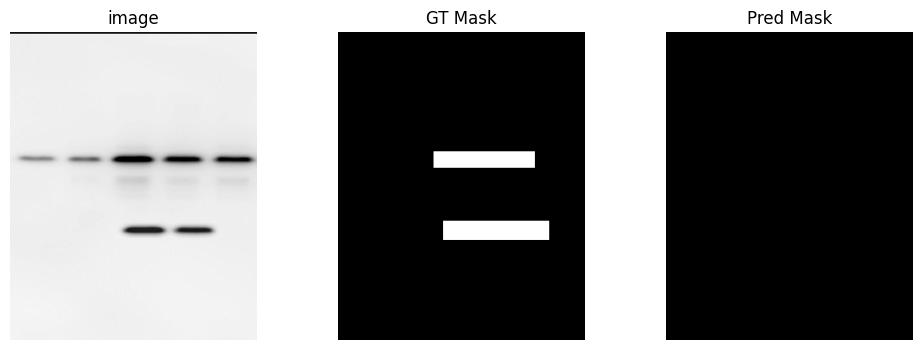

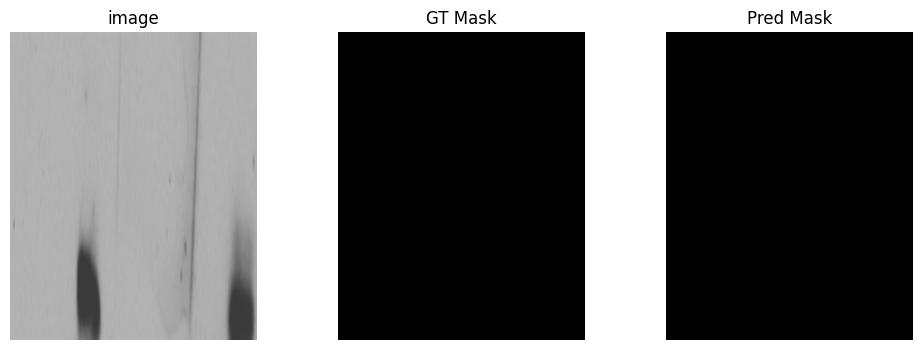

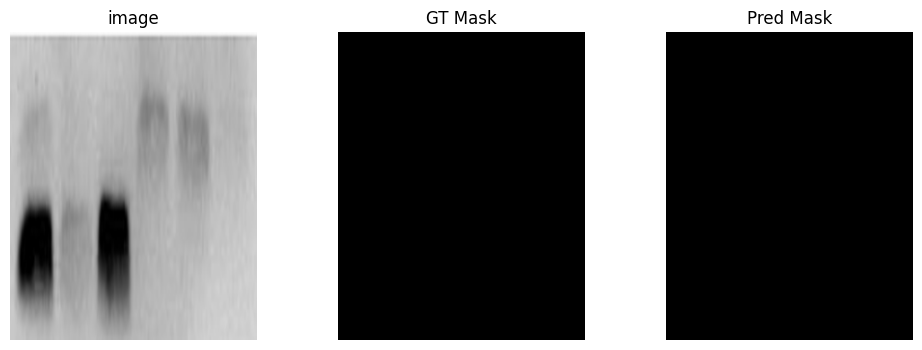

In [73]:
visualize_batch(model, val_loader, device)

In [24]:
def dice_score(pred, gt, eps=1e-6):
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum()
    return (2 * intersection + eps) / (union + eps)


def iou_score(pred, gt, eps=1e-6):
    intersection = (pred * gt).sum()
    union = pred.sum() + gt.sum() - intersection
    return (intersection + eps) / (union + eps)

def soft_dice_score(probs, gt, eps=1e-6):
    intersection = (probs * gt).sum()
    union = probs.sum() + gt.sum()
    return (2 * intersection + eps) / (union + eps)

def soft_iou_score(probs, gt, eps=1e-6):
    intersection = (probs * gt).sum()
    union = probs.sum() + gt.sum() - intersection
    return (intersection + eps) / (union + eps)


In [79]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, loader, device, threshold=0.5):
    model.eval()

    y_true_img = []
    y_pred_img = []

    dice_scores = []
    iou_scores = []


    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            for i in range(images.size(0)):
                gt_mask = masks[i, 0]
                prob_map = probs[i, 0]

                pred_bin = (prob_map > threshold).float()

                gt_is_forged = int(gt_mask.sum() > 0)
                pred_is_forged = int(pred_bin.sum() > 0)

                y_true_img.append(gt_is_forged)
                y_pred_img.append(pred_is_forged)

                if gt_is_forged:
                    dice = soft_dice_score(prob_map, gt_mask)
                    iou = soft_iou_score(prob_map, gt_mask)

                    dice_scores.append(dice.item())
                    iou_scores.append(iou.item())

                

    image_metrics = {
        "accuracy": accuracy_score(y_true_img, y_pred_img),
        "precision": precision_score(y_true_img, y_pred_img, zero_division=0),
        "recall": recall_score(y_true_img, y_pred_img, zero_division=0),
        "f1": f1_score(y_true_img, y_pred_img, zero_division=0),
    }

    pixel_metrics = {
        "mean_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "mean_iou": sum(iou_scores) / len(iou_scores) if iou_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }

    return image_metrics, pixel_metrics
    

In [80]:
img_metrics, pix_metrics = evaluate_model(model, val_loader, device)

print("Image-level metrics: ")
for k, v in img_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nPixel-level metrics (for forged images only):")
for k, v in pix_metrics.items():
    print(f"{k}: {v:.4f}")

Image-level metrics: 
accuracy: 0.4468
precision: 0.0000
recall: 0.0000
f1: 0.0000

Pixel-level metrics (for forged images only):
mean_dice: 0.0760
mean_iou: 0.0419
num_forged_samples: 567.0000


# U-Net Reached the Limit


# New Phase: Decoupling Detection and Loclization 

In [16]:
unet = UNet().to(device)
unet.load_state_dict(torch.load("unet_baseline.pth", map_location=device))
unet.eval()

for param in unet.parameters():
    param.requires_grad = False

In [17]:
class UNetWithClassifier(nn.Module):
    def __init__(self, unet):
        super().__init__()
        self.unet = unet

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(), 
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        e1 = self.unet.enc1(x)
        e2 = self.unet.enc2(self.unet.pool(e1))
        e3 = self.unet.enc3(self.unet.pool(e2))
        bottleneck = self.unet.bottleneck(self.unet.pool(e3))

        d3 = self.unet.up3(bottleneck)
        d3 = self.unet.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.unet.up2(d3)
        d2 = self.unet.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.unet.up1(d2)
        d1 = self.unet.dec1(torch.cat([d1, e1], dim=1))

        seg_logits = self.unet.out(d1)

        cls_logit = self.classifier(bottleneck)

        return seg_logits, cls_logit


In [18]:
model = UNetWithClassifier(unet).to(device)

In [19]:
images, masks = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    seg_logits, cls_logits = model(images)

print("Segmentation output shape: ", seg_logits.shape)
print("Classification output shape: ", cls_logits.shape)

Segmentation output shape:  torch.Size([4, 1, 320, 256])
Classification output shape:  torch.Size([4, 1])


In [23]:
for param in model.unet.parameters():
    param.require_grad = False

In [24]:
cls_criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)

In [25]:
def train_classifier_epoch(model, loader, device):
    model.train()
    total_loss = 0.0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        img_labels = (masks.sum(dim=(1,2,3)) > 0).float().to(device)

        _, cls_logits = model(images)
        cls_logits = cls_logits.squeeze(1)

        loss = cls_criterion(cls_logits, img_labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        return total_loss / len(loader)

In [26]:
for epoch in range(20):
    loss = train_classifier_epoch(model, train_loader, device)
    print(f"classifier Epoch [{epoch+1}/5] | Loss: {loss:.4f}")

classifier Epoch [1/5] | Loss: 0.0007
classifier Epoch [2/5] | Loss: 0.0006
classifier Epoch [3/5] | Loss: 0.0012
classifier Epoch [4/5] | Loss: 0.0006
classifier Epoch [5/5] | Loss: 0.0006
classifier Epoch [6/5] | Loss: 0.0005
classifier Epoch [7/5] | Loss: 0.0005
classifier Epoch [8/5] | Loss: 0.0010
classifier Epoch [9/5] | Loss: 0.0009
classifier Epoch [10/5] | Loss: 0.0006
classifier Epoch [11/5] | Loss: 0.0008
classifier Epoch [12/5] | Loss: 0.0006
classifier Epoch [13/5] | Loss: 0.0007
classifier Epoch [14/5] | Loss: 0.0007
classifier Epoch [15/5] | Loss: 0.0007
classifier Epoch [16/5] | Loss: 0.0007
classifier Epoch [17/5] | Loss: 0.0006
classifier Epoch [18/5] | Loss: 0.0007
classifier Epoch [19/5] | Loss: 0.0007
classifier Epoch [20/5] | Loss: 0.0006


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_classifier(model, loader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():

        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            img_labels = (masks.sum(dim=(1,2,3)) > 0).float()

            _, cls_logits = model(images)
            probs = torch.sigmoid(cls_logits).squeeze(1)

            preds = (probs > threshold).float()

            y_true.extend(img_labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

        return{
            "accuracy": accuracy_score(y_true, y_pred), 
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0)
        }

In [28]:
cls_metrics = evaluate_classifier(model, val_loader, device)
print(cls_metrics)

{'accuracy': 0.5004878048780488, 'precision': 0.5444015444015444, 'recall': 0.5053763440860215, 'f1': 0.5241635687732342}


# Gate Segmentation Using Classifier Output

In [5]:
def evaluate_with_gating(model, loader, device, cls_threshold=0.5, seg_threshold=0.5):
    model.eval()
    
    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            seg_logits, cls_logits = model(images)
            seg_probs = torch.sigmoid(seg_logits)
            cls_probs = torch.sigmoid(cls_logits)

            for i in range(images.size(0)):
                gt_mask = masks[i, 0]

                is_forged = cls_probs[i].item() > cls_threshold

                if not is_forged:
                    pred_mask = torch.zeros_like(gt_mask)

                else:
                    pred_mask = seg_probs[i, 0]
                
                if gt_mask.sum() > 0:
                    dice = soft_dice_score(pred_mask, gt_mask)
                    iou = soft_iou_score(pred_mask, gt_mask)

                    dice_scores.append(dice.item())
                    iou_scores.append(iou.item())

    
    return{
        "mean_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "mean_iou": sum(iou_scores) / len(iou_scores) if iou_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }

In [6]:
gated_metrics = evaluate_with_gating(model, val_loader, device)
print(gated_metrics)

NameError: name 'model' is not defined

# Unfreezing Decoder & re-training (seg + cls) 

In [39]:
for param in model.parameters():
    param.requires_grad = False

for name, param in model.named_parameters():
    if any(k in name for k in ["bottleneck", "up", "dec", "classifier"]):
        param.requires_grad = True

In [40]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [41]:
seg_loss_fn = DiceLoss()
cls_loss_fn = nn.BCEWithLogitsLoss()

def joint_loss(seg_logits, cls_logits, masks):
    seg_loss = seg_loss_fn(seg_logits, masks)

    img_labels = (masks.sum(dim=(1,2,3)) > 0).float().unsqueeze(1)
    cls_loss = cls_loss_fn(cls_logits, img_labels)

    return seg_loss + 0.3 * cls_loss

In [44]:
num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, masks in train_loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        seg_logits, cls_logits = model(images)
        loss = joint_loss(seg_logits, cls_logits, masks)
        
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}] | Loss: {running_loss/len(train_loader):.4f}")

Epoch [1/20] | Loss: 0.7419
Epoch [2/20] | Loss: 0.7419
Epoch [3/20] | Loss: 0.7419
Epoch [4/20] | Loss: 0.7419
Epoch [5/20] | Loss: 0.7418
Epoch [6/20] | Loss: 0.7418
Epoch [7/20] | Loss: 0.7420
Epoch [8/20] | Loss: 0.7416
Epoch [9/20] | Loss: 0.7419
Epoch [10/20] | Loss: 0.7417
Epoch [11/20] | Loss: 0.7414
Epoch [12/20] | Loss: 0.7415
Epoch [13/20] | Loss: 0.7417
Epoch [14/20] | Loss: 0.7417
Epoch [15/20] | Loss: 0.7417
Epoch [16/20] | Loss: 0.7415
Epoch [17/20] | Loss: 0.7415
Epoch [18/20] | Loss: 0.7417
Epoch [19/20] | Loss: 0.7417
Epoch [20/20] | Loss: 0.7416


# Attention U-Net

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        """
        F_g   : channels of decoder feature (gating signal)
        F_l   : channels of encoder feature (skip connection)
        F_int : intermediate channels
        """
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, bias=True),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        """
        x : encoder feature map
        g : decoder feature map (gating)
        """

        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi



In [11]:
class AttentionUnet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(F_g=256, F_l=256, F_int=128)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(F_g=128, F_l=128, F_int=64)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(F_g=64, F_l=64, F_int=32)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        e3_att = self.att3(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3_att], dim=1))

        d2 = self.up2(d3)
        e2_att = self.att2(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2_att], dim=1)) 

        d1 = self.up1(d2)
        e1_att = self.att1(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1_att], dim=1))

        return self.out(d1)

In [17]:
model = AttentionUnet().to(device)

images, masks = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    out = model(images)

print("Output shape: ", out.shape)

Output shape:  torch.Size([4, 1, 320, 256])


In [20]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

criterion = DiceLoss()

In [26]:
num_epochs = 25

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    print(
        f"Epoch[{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch[1/25] | Train Loss: 0.8630 | Val Loss: 0.8809
Epoch[2/25] | Train Loss: 0.8632 | Val Loss: 0.8648
Epoch[3/25] | Train Loss: 0.8601 | Val Loss: 0.8609
Epoch[4/25] | Train Loss: 0.8588 | Val Loss: 0.8628
Epoch[5/25] | Train Loss: 0.8584 | Val Loss: 0.8675
Epoch[6/25] | Train Loss: 0.8564 | Val Loss: 0.8596
Epoch[7/25] | Train Loss: 0.8541 | Val Loss: 0.8592
Epoch[8/25] | Train Loss: 0.8541 | Val Loss: 0.8572
Epoch[9/25] | Train Loss: 0.8518 | Val Loss: 0.8611
Epoch[10/25] | Train Loss: 0.8517 | Val Loss: 0.8589
Epoch[11/25] | Train Loss: 0.8516 | Val Loss: 0.8634
Epoch[12/25] | Train Loss: 0.8501 | Val Loss: 0.8563
Epoch[13/25] | Train Loss: 0.8493 | Val Loss: 0.8579
Epoch[14/25] | Train Loss: 0.8467 | Val Loss: 0.8566
Epoch[15/25] | Train Loss: 0.8467 | Val Loss: 0.8573
Epoch[16/25] | Train Loss: 0.8435 | Val Loss: 0.8549
Epoch[17/25] | Train Loss: 0.8441 | Val Loss: 0.8535
Epoch[18/25] | Train Loss: 0.8385 | Val Loss: 0.8474
Epoch[19/25] | Train Loss: 0.8355 | Val Loss: 0.8487
Ep

In [27]:
torch.save(model.state_dict(), "attention_unet.pth")

In [11]:
def image_is_forged_from_prob(prob_map, conf_threshold=0.3):
    """
    Decide if an image is forged based on probability statistics,
    NOT raw pixel thresholding.
    """
    return float(prob_map.max()) > conf_threshold


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, loader, device, conf_threshold=0.3):
    model.eval()

    y_true_img = []
    y_pred_img = []

    dice_scores = []
    iou_scores = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            for i in range(images.size(0)):
                gt_mask = masks[i, 0]
                prob_map = probs[i, 0]

                # ---------- Image-level GT ----------
                gt_is_forged = int(gt_mask.sum() > 0)

                # ---------- Image-level Prediction (FIXED) ----------
                pred_is_forged = image_is_forged_from_prob(
                    prob_map, conf_threshold
                )

                y_true_img.append(gt_is_forged)
                y_pred_img.append(int(pred_is_forged))

                # ---------- Pixel-level metrics (FORGED ONLY) ----------
                if gt_is_forged:
                    dice = soft_dice_score(prob_map, gt_mask)
                    iou = soft_iou_score(prob_map, gt_mask)

                    dice_scores.append(dice.item())
                    iou_scores.append(iou.item())

    image_metrics = {
        "accuracy": accuracy_score(y_true_img, y_pred_img),
        "precision": precision_score(y_true_img, y_pred_img, zero_division=0),
        "recall": recall_score(y_true_img, y_pred_img, zero_division=0),
        "f1": f1_score(y_true_img, y_pred_img, zero_division=0),
    }

    pixel_metrics = {
        "mean_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "mean_iou": sum(iou_scores) / len(iou_scores) if iou_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }

    return image_metrics, pixel_metrics


In [31]:
att_metrics = evaluate_model(model, val_loader, device)
print(att_metrics)

({'accuracy': 0.5395121951219513, 'precision': 0.5380710659898477, 'recall': 0.9689213893967094, 'f1': 0.6919060052219321}, {'mean_dice': 0.29060543116874576, 'mean_iou': 0.1990726806014901, 'num_forged_samples': 547})


In [13]:
def hard_dice_score(prob_map, gt_mask, threshold=0.5, eps=1e-6):
    """
    prob_map : torch.Tensor (H, W) - sigmoid output
    gt_mask  : torch.Tensor (H, W) - ground truth {0,1}
    """
    pred_bin = (prob_map > threshold).float()

    intersection = (pred_bin * gt_mask).sum()
    union = pred_bin.sum() + gt_mask.sum()

    return (2 * intersection + eps) / (union + eps)

@torch.no_grad()
def evaluate_hard_dice(model, loader, device, threshold=0.5):
    model.eval()
    dice_scores = []

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)

        for i in range(images.size(0)):
            gt_mask = masks[i, 0]

            # only forged samples
            if gt_mask.sum() > 0:
                dice = hard_dice_score(probs[i, 0], gt_mask, threshold)
                dice_scores.append(dice.item())

    return {
        "mean_hard_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }



In [33]:
hard_metrics = evaluate_hard_dice(model, val_loader, device, threshold=0.5)

print(hard_metrics)


{'mean_hard_dice': 0.2911457216277981, 'num_forged_samples': 547}


In [16]:
import torch
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_confusion_matrix(model, loader, device, threshold=0.5):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits)

            for i in range(images.size(0)):
                gt_mask = masks[i, 0]
                prob_map = probs[i, 0]

                gt_label = int(gt_mask.sum() > 0)
                pred_label = int((prob_map > threshold).sum() > 0)

                y_true.append(gt_label)
                y_pred.append(pred_label)

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, 
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Authentic", "Forged"],
        yticklabels=["Authentic", "Forged"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Ground Truth")
    plt.title("Confusion Matrix (Image-level)")
    plt.show()

    return cm

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AttentionUnet().to(device)
model.load_state_dict(torch.load("attention_unet.pth", map_location=device))
model.eval()

AttentionUnet(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(128, 256, 

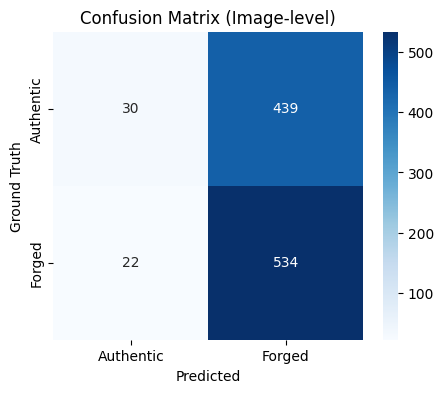

[[ 30 439]
 [ 22 534]]


In [17]:
cm = plot_confusion_matrix(model, val_loader, device, threshold=0.5)
print(cm)

# EfficientNet + Attention U - Net  

In [7]:
import torch
import torch.nn as nn 
from torchvision import models

efficientnet = models.efficientnet_b0(weights="IMAGENET1K_V1")

In [8]:
import torch
import torch.nn as nn
from torchvision import models

class EfficientNetEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")

        self.stem = base.features[0]
        self.block1 = base.features[1]
        self.block2 = base.features[2]
        self.block3 = base.features[3]
        self.block4 = base.features[4]
        self.block5 = base.features[5]
        self.block6 = base.features[6]
        self.block7 = base.features[7]
        self.head = base.features[8]

    def forward(self, x):
        x0 = self.stem(x)
        x1 = self.block1(x0)
        x2 = self.block2(x1)
        x3 = self.block3(x2)
        x4 = self.block4(x3)
        x5 = self.block5(x4)
        x6 = self.block6(x5)
        x7 = self.block7(x6)
        x8 = self.head(x7)

        return x0, x1, x2, x3, x4, x5, x6, x7, x8


In [9]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Conv2d(F_g, F_int, 1, bias=False)
        self.W_x = nn.Conv2d(F_l, F_int, 1, bias=False)
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1), 
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):

        if g.shape[2:] != x.shape[2:]:
            g = F.interpolate(g, size=x.shape[2:], mode="bilinear", align_corners=False)
            
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch , 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)
    
class DecodeBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.att = AttentionGate(out_ch, skip_ch, out_ch // 2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear", align_corners=False)
            

        skip = self.att(skip, x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

In [11]:
class EfficientAttentionUnet(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = EfficientNetEncoder()

        self.bottleneck = DoubleConv(1280, 512)

        self.dec4 = DecodeBlock(512, 320, 256)
        self.dec3 = DecodeBlock(256, 192, 128)
        self.dec2 = DecodeBlock(128, 112, 64)
        self.dec1 = DecodeBlock(64, 80, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        _, _, _, _, x4, x5, x6, x7, x8 = self.encoder(x)

        b = self.bottleneck(x8)
        
        d4 = self.dec4(b, x7)
        d3 = self.dec3(d4, x6)
        d2 = self.dec2(d3, x5)
        d1 = self.dec1(d2, x4)

        out = self.out(d1)
        out = F.interpolate(
            out, 
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        return out

In [14]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = EfficientAttentionUnet().to(device)
model.eval()

images, _ = next(iter(train_loader))
images = images.to(device)

with torch.no_grad():
    outputs = model(images)

print(outputs.shape)

torch.Size([4, 1, 320, 256])


In [15]:
for param in model.encoder.parameters():
    param.requires_grad = False

# Dice Loss to be used

In [16]:
bce = nn.BCEWithLogitsLoss()

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        intersection = (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))
        dice = (2 * intersection + self.eps) / (union + self.eps)
        return 1 - dice.mean()
    
dice = DiceLoss()

def criterion(logits, masks):
    return bce(logits, masks) + dice(logits, masks)

In [18]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)

In [19]:
print(sum(p.requires_grad for p in model.parameters()))

82


In [20]:
num_epochs = 25

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = validate_one_epoch(model, val_loader, criterion)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/25] | Train Loss: 1.0595 | Val Loss: 1.0004
Epoch [2/25] | Train Loss: 0.9888 | Val Loss: 0.9812
Epoch [3/25] | Train Loss: 0.9727 | Val Loss: 0.9818
Epoch [4/25] | Train Loss: 0.9625 | Val Loss: 0.9638
Epoch [5/25] | Train Loss: 0.9524 | Val Loss: 0.9603
Epoch [6/25] | Train Loss: 0.9437 | Val Loss: 0.9578
Epoch [7/25] | Train Loss: 0.9352 | Val Loss: 0.9615
Epoch [8/25] | Train Loss: 0.9317 | Val Loss: 0.9619
Epoch [9/25] | Train Loss: 0.9207 | Val Loss: 0.9658
Epoch [10/25] | Train Loss: 0.9145 | Val Loss: 0.9640
Epoch [11/25] | Train Loss: 0.9085 | Val Loss: 0.9732
Epoch [12/25] | Train Loss: 0.9024 | Val Loss: 0.9694
Epoch [13/25] | Train Loss: 0.8958 | Val Loss: 0.9657
Epoch [14/25] | Train Loss: 0.8881 | Val Loss: 0.9759
Epoch [15/25] | Train Loss: 0.8793 | Val Loss: 0.9865
Epoch [16/25] | Train Loss: 0.8757 | Val Loss: 0.9761
Epoch [17/25] | Train Loss: 0.8728 | Val Loss: 0.9827
Epoch [18/25] | Train Loss: 0.8645 | Val Loss: 0.9859
Epoch [19/25] | Train Loss: 0.8587 | 

In [21]:
model.eval()

EfficientAttentionUnet(
  (encoder): EfficientNetEncoder(
    (stem): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (block1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
      

In [22]:
@torch.no_grad()
def evaluate_hard_dice(model, loader, device, threshold=0.5):
    model.eval()

    dice_scores = []

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)

        for i in range(images.size(0)):
            gt = masks[i, 0]
            pred = (probs[i, 0] > threshold).float()

            if gt.sum() > 0:
                dice = dice_score(pred, gt)
                dice_scores.append(dice.item())

    return{
        "mean_hard_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }

In [1]:
hard_dice_result = evaluate_hard_dice(model, val_loader, device)
hard_dice_result 

NameError: name 'evaluate_hard_dice' is not defined

# Attention U-Net + Self Correlation Block (Harder Traning for Analysis)

In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class CorrelationBlock(nn.Module):
    """
    Explicit self-similarity (non-local) block
    """
    def __init__(self, in_channels):
        super().__init__()

        self.theta = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.phi   = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.g     = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)

        self.out_conv = nn.Conv2d(in_channels // 2, in_channels, kernel_size=1)
        self.scale = (in_channels // 2) ** -0.5

    def forward(self, x):
        """
        x: (B, C, H, W)
        """
        B, C, H, W = x.shape

        theta = self.theta(x).view(B, -1, H * W)          # (B, C', N)
        phi   = self.phi(x).view(B, -1, H * W)            # (B, C', N)
        g     = self.g(x).view(B, -1, H * W)              # (B, C', N)

        theta = theta.permute(0, 2, 1)                    # (B, N, C')
        affinity = torch.bmm(theta, phi) * self.scale    # (B, N, N)
        affinity = F.softmax(affinity, dim=-1)

        out = torch.bmm(g, affinity.permute(0, 2, 1))    # (B, C', N)
        out = out.view(B, -1, H, W)

        out = self.out_conv(out)

        return x + out   # residual


In [8]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, bias=False),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi


In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class AttentionUNetWithCorrelation(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)
        self.corr = CorrelationBlock(512)   # 🔥 KEY ADDITION

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.att3 = AttentionGate(256, 256, 128)
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.att2 = AttentionGate(128, 128, 64)
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.att1 = AttentionGate(64, 64, 32)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))
        b = self.corr(b)   # ← correlation-aware bottleneck

        d3 = self.up3(b)
        e3 = self.att3(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        e2 = self.att2(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        e1 = self.att1(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out(d1)


In [10]:
class ConditionalDiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)

        B = probs.shape[0]
        losses = []

        for i in range(B):
            p = probs[i]
            y = targets[i]

            y_sum = y.sum()

            if y_sum > 0:
                intersection = (p * y).sum()
                union = p.sum() + y_sum
                dice = (2 * intersection + self.eps) / (union + self.eps)
                loss = 1 - dice
            
            else:
                loss = p.mean()

            losses.append(loss)
        
        return torch.stack(losses).mean()

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = AttentionUNetWithCorrelation().to(device)
criterion = ConditionalDiceLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)


In [26]:
num_epochs = 100
best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate_one_epoch(model, val_loader, criterion)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    )

    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_val_loss_model.pth")


Epoch [1/100] | Train Loss: 0.5772 | Val Loss: 0.5199
Epoch [2/100] | Train Loss: 0.5082 | Val Loss: 0.4833
Epoch [3/100] | Train Loss: 0.4748 | Val Loss: 0.4679
Epoch [4/100] | Train Loss: 0.4553 | Val Loss: 0.4408
Epoch [5/100] | Train Loss: 0.4468 | Val Loss: 0.4384
Epoch [6/100] | Train Loss: 0.4389 | Val Loss: 0.4396
Epoch [7/100] | Train Loss: 0.4349 | Val Loss: 0.4295
Epoch [8/100] | Train Loss: 0.4325 | Val Loss: 0.4246
Epoch [9/100] | Train Loss: 0.4274 | Val Loss: 0.4259
Epoch [10/100] | Train Loss: 0.4252 | Val Loss: 0.4261
Epoch [11/100] | Train Loss: 0.4230 | Val Loss: 0.4227
Epoch [12/100] | Train Loss: 0.4208 | Val Loss: 0.4199
Epoch [13/100] | Train Loss: 0.4147 | Val Loss: 0.4288
Epoch [14/100] | Train Loss: 0.4164 | Val Loss: 0.4143
Epoch [15/100] | Train Loss: 0.4077 | Val Loss: 0.4122
Epoch [16/100] | Train Loss: 0.4044 | Val Loss: 0.4043
Epoch [17/100] | Train Loss: 0.3988 | Val Loss: 0.4141
Epoch [18/100] | Train Loss: 0.3961 | Val Loss: 0.4087
Epoch [19/100] | Tr

KeyboardInterrupt: 

In [14]:
model.load_state_dict(torch.load("best_val_loss_model.pth"))
model.eval()


C:\Users\asuss\AppData\Local\Temp\ipykernel_7440\729390927.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_val_loss_model.pth"))


AttentionUNetWithCorrelation(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Co

In [17]:
import numpy as np
from sklearn.metrics import precision_score, recall_score
import torch

def threshold_sweep(model, loader, device):

    thresholds = np.arange(0.05, 0.96, 0.05)

    best_dice = 0
    best_results = None

    model.eval()

    with torch.no_grad():

        all_probs = []
        all_gts   = []

        # collect predictions once (important)
        for images, masks in loader:
            images = images.to(device)
            logits = model(images)
            probs  = torch.sigmoid(logits).cpu()

            all_probs.append(probs)
            all_gts.append(masks)

        all_probs = torch.cat(all_probs)
        all_gts   = torch.cat(all_gts)

        for t in thresholds:

            preds = (all_probs > t).float()

            dice_scores = []
            iou_scores  = []

            y_true = []
            y_pred = []

            for i in range(preds.shape[0]):

                pr = preds[i,0].numpy().flatten()
                gt = all_gts[i,0].numpy().flatten()

                intersection = (pr * gt).sum()
                union = pr.sum() + gt.sum()

                if gt.sum() > 0:
                    dice = (2*intersection + 1e-6)/(union + 1e-6)
                    iou  = (intersection + 1e-6)/((pr + gt - pr*gt).sum() + 1e-6)

                    dice_scores.append(dice)
                    iou_scores.append(iou)

                y_true.extend(gt)
                y_pred.extend(pr)

            precision = precision_score(y_true, y_pred, zero_division=0)
            recall    = recall_score(y_true, y_pred, zero_division=0)

            mean_dice = np.mean(dice_scores)

            if mean_dice > best_dice:
                best_dice = mean_dice
                best_results = {
                    "threshold": t,
                    "dice": mean_dice,
                    "iou": np.mean(iou_scores),
                    "precision": precision,
                    "recall": recall
                }

    return best_results


In [19]:
best_metrics = threshold_sweep(model, val_loader, device)
print("Best Threshold Results:")
print(best_metrics)


Best Threshold Results:
{'threshold': np.float64(0.05), 'dice': np.float32(0.41029674), 'iou': np.float32(0.2993568), 'precision': 0.34202928981667174, 'recall': 0.4928072505999314}


In [27]:
if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_val_loss_model.pth")

# 15 Samples for Clarification

In [12]:
import matplotlib.pyplot as plt
import torch
import numpy as np

def visualize_failures(model, loader, device, num_samples=15):
    model.eval()
    shown = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            preds = model(images)
            preds_bin = (preds > 0.5).float()

            for i in range(images.size(0)):
                img = images[i].cpu().permute(1,2,0).numpy()
                gt = masks[i].cpu().squeeze().numpy()
                pr = preds_bin[i].cpu().squeeze().numpy()

                # Compute Dice
                intersection = (pr * gt).sum()
                union = pr.sum() + gt.sum()
                dice = (2*intersection + 1e-6) / (union + 1e-6)

                # Only show imperfect cases
                if dice < 0.6:
                    plt.figure(figsize=(10,3))

                    plt.subplot(1,3,1)
                    plt.imshow(img)
                    plt.title("Image")
                    plt.axis("off")

                    plt.subplot(1,3,2)
                    plt.imshow(gt, cmap="gray")
                    plt.title("Ground Truth")
                    plt.axis("off")

                    plt.subplot(1,3,3)
                    plt.imshow(pr, cmap="gray")
                    plt.title(f"Prediction\nDice={dice:.2f}")
                    plt.axis("off")

                    plt.show()

                    shown += 1
                    if shown >= num_samples:
                        return


In [13]:
checkpoint = torch.load("best_val_loss_model.pth", map_location=device)
model.load_state_dict(checkpoint)
model.eval()


C:\Users\asuss\AppData\Local\Temp\ipykernel_30504\4130124493.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load("best_val_loss_model.pth", map_locat

AttentionUNetWithCorrelation(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Co

In [15]:
x = torch.randn(1, 3, 320, 256).to(device)
y = model(x)
print(y.shape)


torch.Size([1, 1, 320, 256])


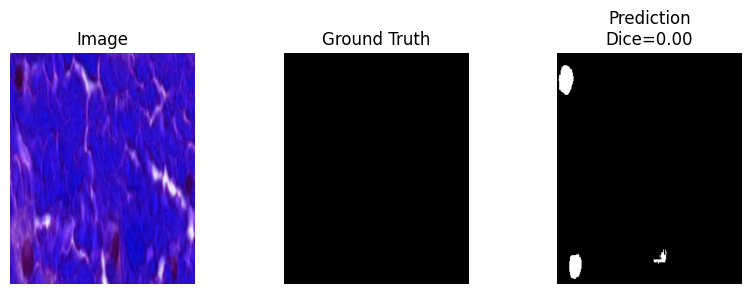

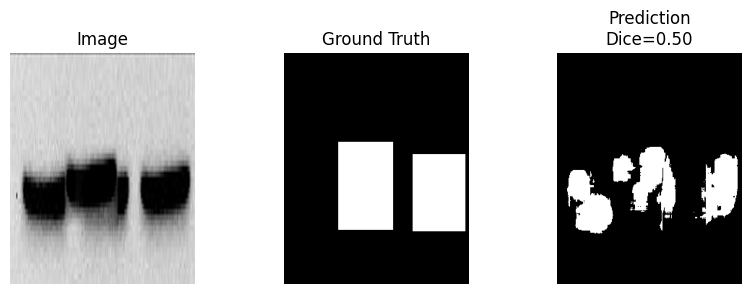

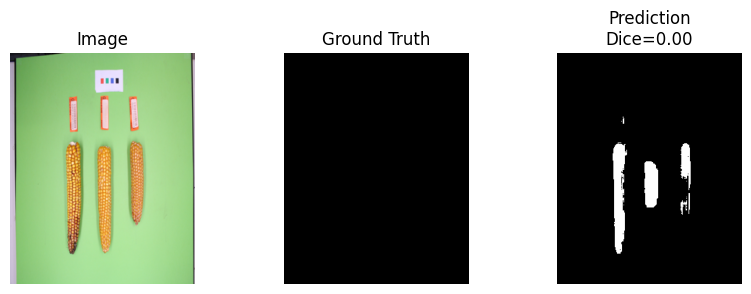

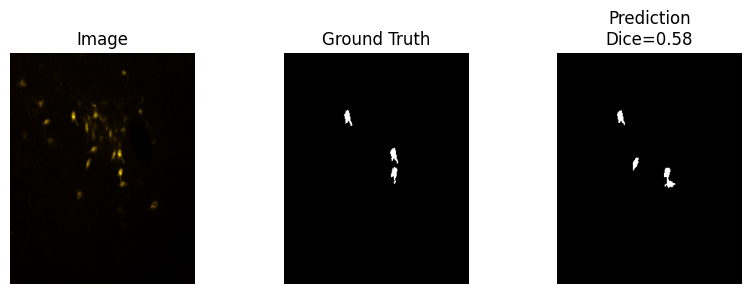

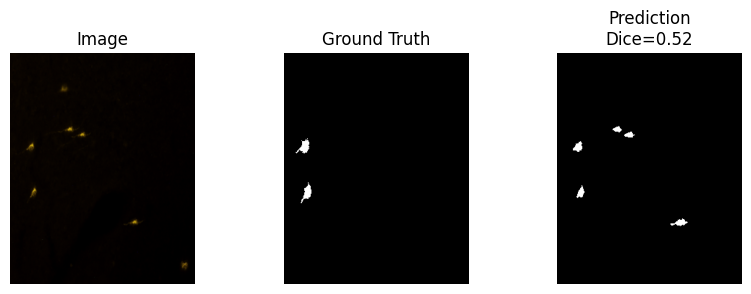

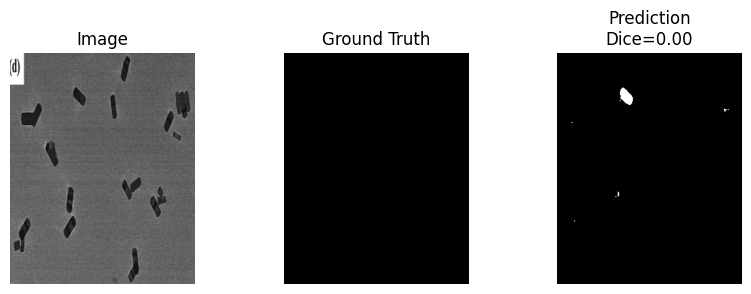

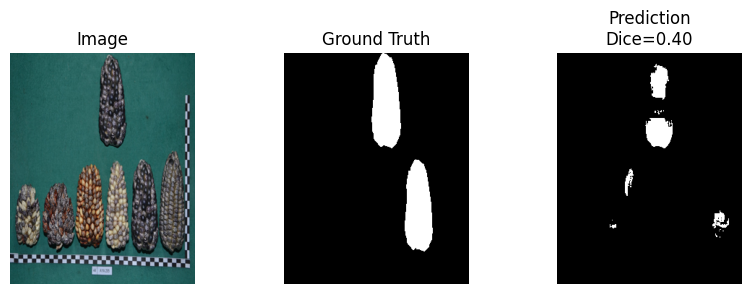

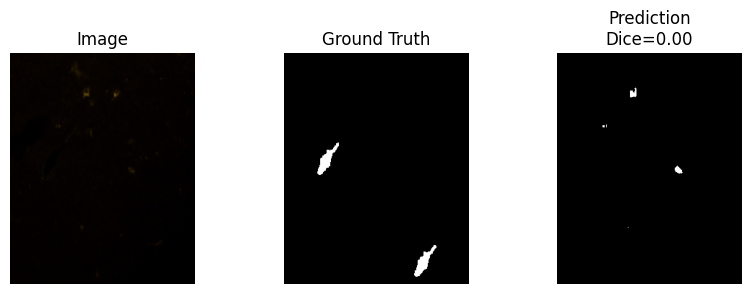

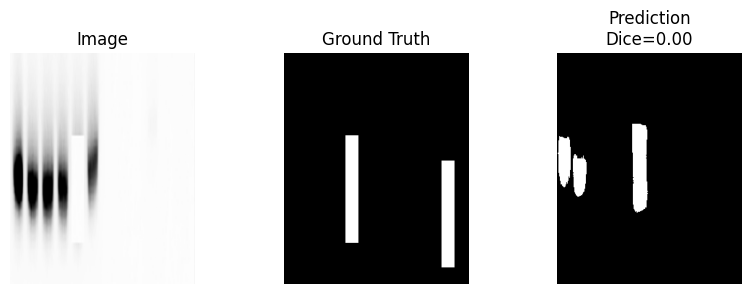

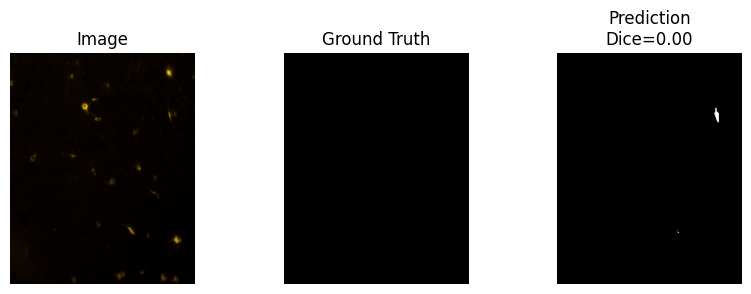

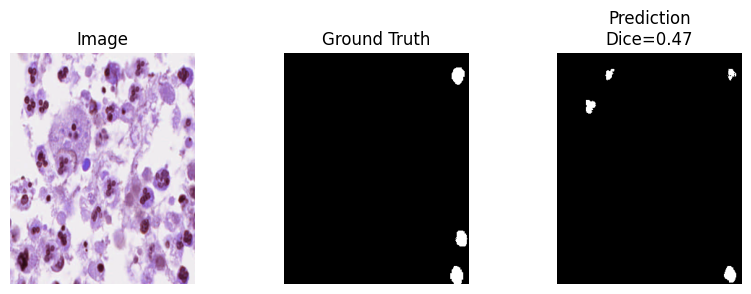

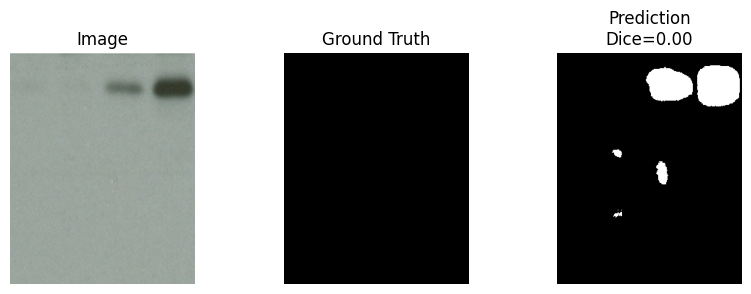

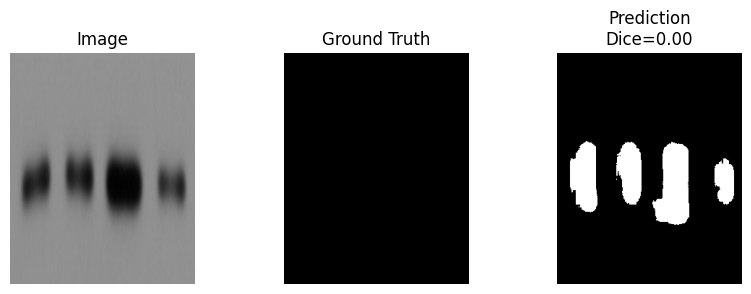

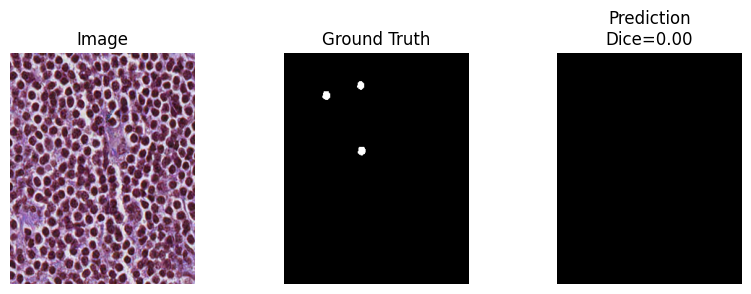

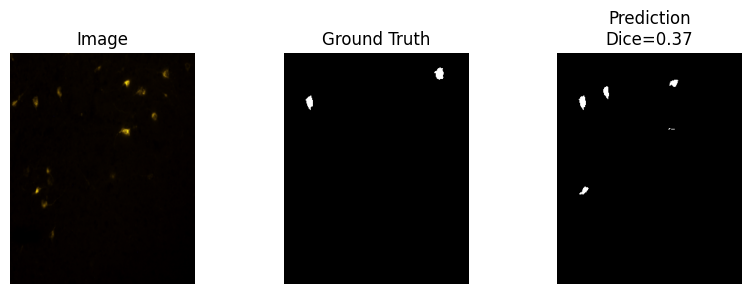

In [16]:
visualize_failures(model, val_loader, device, num_samples=15)


In [14]:
import torch

def hard_dice_score(prob_map, gt_mask, threshold=0.5, eps=1e-6):
    pred = (prob_map > threshold).float()
    intersection = (pred * gt_mask).sum()
    union = pred.sum() + gt_mask.sum()
    return (2 * intersection + eps) / (union + eps)

def hard_iou_score(prob_map, gt_mask, threshold=0.5, eps=1e-6):
    pred = (prob_map > threshold).float()
    intersection = (pred * gt_mask).sum()
    union = pred.sum() + gt_mask.sum() - intersection
    return (intersection + eps) / (union + eps)


In [15]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model.load_state_dict(torch.load("best_val_loss_model.pth", map_location=device))
model.to(device)
model.eval()


AttentionUNetWithCorrelation(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Co

In [16]:
@torch.no_grad()
def evaluate_hard_metrics(model, loader, device, threshold=0.5):
    dice_scores = []
    iou_scores = []

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)

        for i in range(images.size(0)):
            gt_mask = masks[i, 0]

            # evaluate only forged samples
            if gt_mask.sum() > 0:
                prob_map = probs[i, 0]

                dice = hard_dice_score(prob_map, gt_mask, threshold)
                iou  = hard_iou_score(prob_map, gt_mask, threshold)

                dice_scores.append(dice.item())
                iou_scores.append(iou.item())

    return {
        "mean_hard_dice": sum(dice_scores) / len(dice_scores) if dice_scores else 0.0,
        "mean_hard_iou":  sum(iou_scores) / len(iou_scores) if iou_scores else 0.0,
        "num_forged_samples": len(dice_scores)
    }


In [17]:
metrics = evaluate_hard_metrics(
    model,
    val_loader,
    device,
    threshold=0.5
)

print(metrics)


{'mean_hard_dice': 0.022376542628382706, 'mean_hard_iou': 0.014220511970008655, 'num_forged_samples': 545}
